In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                           confusion_matrix,
                           precision_recall_curve,
                           average_precision_score)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import LeaveOneGroupOut

In [10]:
# Load and clean data
data = pd.read_csv('wedowind.csv')
data.drop('Unnamed: 0', axis=1, inplace=True)

# Convert timestamp but don't create temporal features
data['timestamp'] = pd.to_datetime(data['timestamp'])  # Keep only for ordering
data = data[(data['power'] > 0) & (data['rotor_speed'] > 0)]  # Remove invalid rows

# Create targets
data['failure'] = (data['errorcode'] != 0).astype(int)

# Enhanced feature engineering (equipment-focused only)
def create_features(df):
    """Create equipment-based features only"""
    df = df.copy()

    # Sensor-based rolling features
    sensor_cols = ['bearing_temperature', 'hydraulic_pressure', 'rotor_speed',
                  'generator_temperature', 'power']
    for col in sensor_cols:
        if col in df.columns:
            # Rolling statistics
            for window in [3, 6, 12]:  # hours
                df[f'{col}_rolling_mean_{window}h'] = df.groupby('plant_name')[col].transform(
                    lambda x: x.rolling(window, min_periods=1).mean())
                df[f'{col}_rolling_std_{window}h'] = df.groupby('plant_name')[col].transform(
                    lambda x: x.rolling(window, min_periods=1).std())

    # Equipment stress indicators
    if 'power' in df.columns and 'rotor_speed' in df.columns:
        df['power_per_rpm'] = df['power'] / (df['rotor_speed'] + 0.001)
    if 'generator_temperature' in df.columns and 'power' in df.columns:
        df['temp_power_ratio'] = df['generator_temperature'] / (df['power'] + 1)

    return df

data = create_features(data)


In [11]:
# Prepare features - explicitly exclude time-based features
time_features = ['timestamp', 'hour', 'day_of_week', 'day_of_year', 'month']
features = [col for col in data.columns if col not in time_features +
            ['plant_name', 'errorcode', 'failure', 'time_to_failure']]
features = [col for col in features if not col.startswith(('hour_', 'day_', 'month_'))]  # Additional safeguard

In [12]:
# Classification Model (Failure Prediction)
X = data[features]
y = data['failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

model = xgb.XGBClassifier(
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
    max_depth=10,
    learning_rate=0.15,
    subsample=0.8,
    colsample_bytree=0.6,
    eval_metric='logloss',
    n_estimators=300
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [13]:
# Classification Evaluation
# Optimal threshold finding
precision, recall, thresholds = precision_recall_curve(y_test, model.predict_proba(X_test)[:,1])
f1_scores = 2*(precision*recall)/(precision+recall)
optimal_threshold = thresholds[np.argmax(f1_scores)]
y_probs = model.predict_proba(X_test)[:, 1]
y_pred = (y_probs >= optimal_threshold).astype(int)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Failure']))

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99    129842
     Failure       0.91      0.88      0.89     11294

    accuracy                           0.98    141136
   macro avg       0.95      0.93      0.94    141136
weighted avg       0.98      0.98      0.98    141136



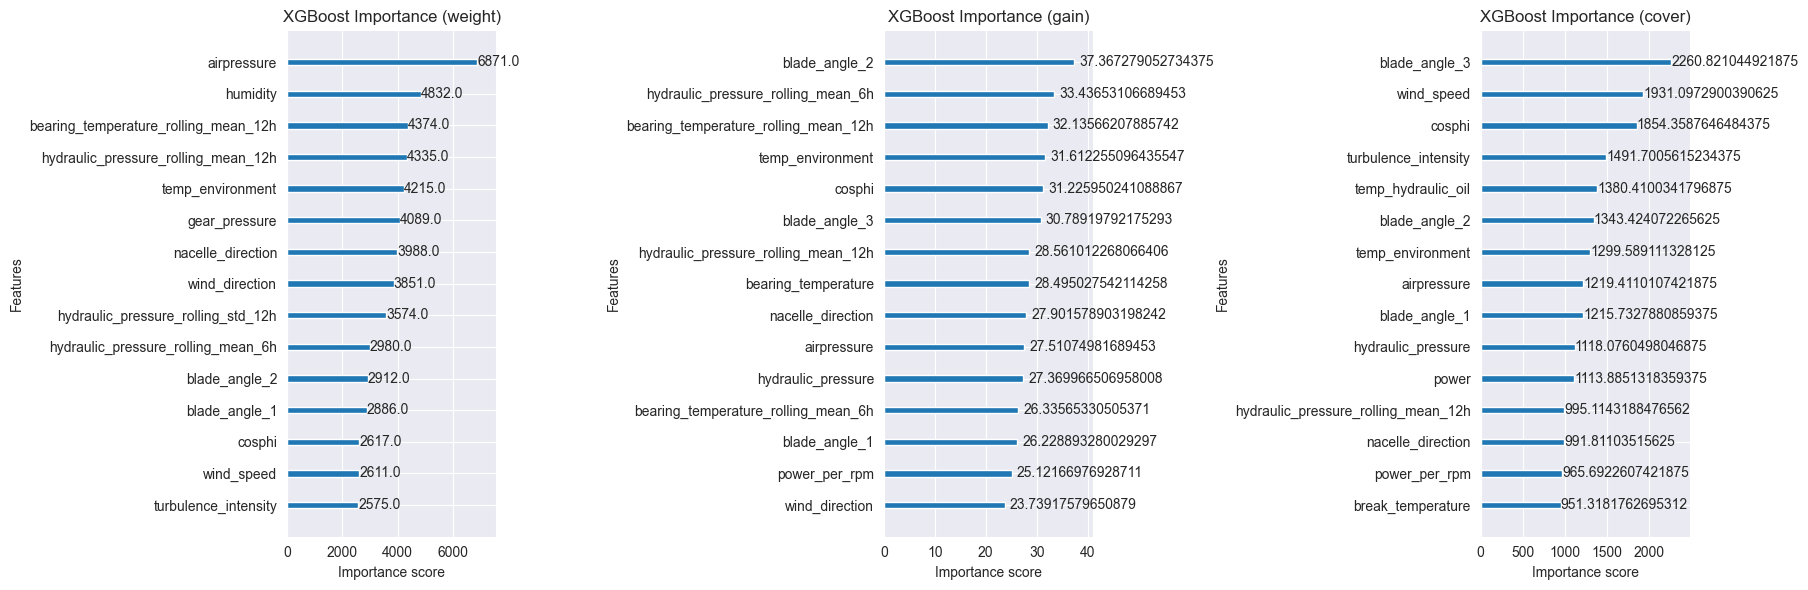

In [14]:
# 3. XGBoost Built-in Feature Importance
importance_types = ['weight', 'gain', 'cover']  # Different importance metrics

# Create a dictionary to store all importance results
importance_results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, imp_type in enumerate(importance_types):
    # Get and store importance values
    importance = model.get_booster().get_score(importance_type=imp_type)
    importance_df = pd.DataFrame({
        'Feature': list(importance.keys()),
        imp_type: list(importance.values())
    }).sort_values(imp_type, ascending=False)

    importance_results[imp_type] = importance_df

    # Plot importance
    xgb.plot_importance(model, importance_type=imp_type, ax=axes[i], max_num_features=15)
    axes[i].set_title(f'XGBoost Importance ({imp_type})')
plt.tight_layout()
plt.show()

In [15]:
# Print importance results
print("\nXGBoost Feature Importance Results:")
for imp_type, df in importance_results.items():
    print(f"\n{imp_type.upper()} Importance:")
    print(df.head(15).to_string(index=False))


XGBoost Feature Importance Results:

WEIGHT Importance:
                             Feature  weight
                         airpressure  6871.0
                            humidity  4832.0
bearing_temperature_rolling_mean_12h  4374.0
 hydraulic_pressure_rolling_mean_12h  4335.0
                    temp_environment  4215.0
                       gear_pressure  4089.0
                   nacelle_direction  3988.0
                      wind_direction  3851.0
  hydraulic_pressure_rolling_std_12h  3574.0
  hydraulic_pressure_rolling_mean_6h  2980.0
                       blade_angle_2  2912.0
                       blade_angle_1  2886.0
                              cosphi  2617.0
                          wind_speed  2611.0
                turbulence_intensity  2575.0

GAIN Importance:
                             Feature      gain
                       blade_angle_2 37.367279
  hydraulic_pressure_rolling_mean_6h 33.436531
bearing_temperature_rolling_mean_12h 32.135662
                 

In [17]:
# Create a TreeExplainer for the XGBoost model
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the training data
shap_values = explainer.shap_values(X_train)


# 1. Enhanced Feature Selection using SHAP and XGBoost Importance only
top_n_features = 15  # Number of top features to select from each method

# Get SHAP-based important features
shap_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'SHAP_Value': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_Value', ascending=False)

# Get consensus important features from all methods
xgb_gain_features = importance_results['gain']['Feature'].head(top_n_features).tolist()
xgb_weight_features = importance_results['weight']['Feature'].head(top_n_features).tolist()
xgb_cover_features = importance_results['cover']['Feature'].head(top_n_features).tolist()
shap_top_features = shap_importance.head(top_n_features)['Feature'].tolist()

# Combine all important features (excluding temporal features)
selected_features = list(set(
    xgb_gain_features + xgb_weight_features + xgb_cover_features + shap_top_features
))

# Filter out any remaining temporal features if they exist
temporal_keywords = ['hour', 'day', 'month', 'year', 'timestamp']
selected_features = [feat for feat in selected_features
                    if not any(keyword in feat.lower() for keyword in temporal_keywords)]

# Create a summary table of feature importance
feature_importance_summary = shap_importance.set_index('Feature')
for imp_type in importance_types:
    feature_importance_summary = feature_importance_summary.join(
        importance_results[imp_type].set_index('Feature'),
        how='outer'
    )

print("\nCombined Feature Importance Summary (Non-Temporal Features):")
print(feature_importance_summary.loc[
    feature_importance_summary.index.isin(selected_features)
].sort_values('SHAP_Value', ascending=False).to_string())

print("\nFinal Selected Features (Excluding Temporal Features):")
print(selected_features)


Combined Feature Importance Summary (Non-Temporal Features):
                                      SHAP_Value  weight       gain        cover
Feature                                                                         
wind_speed                              0.585693  2611.0  22.769293  1931.097290
airpressure                             0.540717  6871.0  27.510750  1219.411011
temp_environment                        0.444115  4215.0  31.612255  1299.589111
blade_angle_2                           0.404810  2912.0  37.367279  1343.424072
blade_angle_3                           0.376471  2418.0  30.789198  2260.821045
nacelle_direction                       0.354037  3988.0  27.901579   991.811035
cosphi                                  0.344398  2617.0  31.225950  1854.358765
humidity                                0.341012  4832.0  21.078716   871.996704
hydraulic_pressure_rolling_mean_12h     0.332911  4335.0  28.561012   995.114319
bearing_temperature_rolling_mean_12h    0.32269

In [18]:
def create_ttf_feature(group):
    """Create Time-to-Failure feature"""
    group = group.sort_values('timestamp')
    group['ttf'] = 0.0
    failure_indices = group.index[group['failure'] == 1].tolist()

    for i in range(len(group)):
        current_time = group.iloc[i]['timestamp']
        future_failures = group[(group['timestamp'] > current_time) & (group['failure'] == 1)]

        if not future_failures.empty:
            next_failure_time = future_failures.iloc[0]['timestamp']
            ttf_hours = (next_failure_time - current_time).total_seconds() / 3600
            group.loc[group.index[i], 'ttf'] = ttf_hours
        else:
            group.loc[group.index[i], 'ttf'] = np.nan
    return group

# Apply to your data
data_ttf = data.groupby('plant_name', group_keys=False).apply(create_ttf_feature)

# 2. Clean and filter the data
data_ttf = data_ttf.dropna(subset=['ttf'])  # Remove unknown TTF
data_ttf = data_ttf[(data_ttf['ttf'] <= 15) & (data_ttf['ttf'] > 0)]  # Last 15h before failure
data_ttf = data_ttf[data_ttf['failure'] == 0]  # Remove actual failure points


C:\Users\usuario\AppData\Local\Temp\ipykernel_23304\2385974386.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_ttf = data.groupby('plant_name', group_keys=False).apply(create_ttf_feature)


In [19]:
# 3. Feature selection (ensure selected_features exists)
if 'selected_features' not in locals():
    # If not defined, use all non-temporal features
    temporal_keywords = ['timestamp', 'hour', 'day', 'month', 'year']
    selected_features = [col for col in data_ttf.columns
                        if not any(kw in col for kw in temporal_keywords)
                        and col not in ['failure', 'errorcode', 'plant_name', 'ttf']]


In [20]:
# 4. Prepare features and target
features = [col for col in selected_features if col in data_ttf.columns]
X = data_ttf[features]
y = data_ttf['ttf']
groups = data_ttf['plant_name']

# 5. XGBoost Regressor Implementation
logo = LeaveOneGroupOut()
mae_results_xgb = {}
predictions_xgb = {}

In [22]:
from xgboost import XGBRegressor

for train_index, test_index in logo.split(X, y, groups):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    turbine_id = groups.iloc[test_index[0]]

    # Train XGBoost Regressor with optimized parameters
    xgb_reg = XGBRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror',
        eval_metric='mae'
    )

    xgb_reg.fit(X_train, y_train,
               eval_set=[(X_test, y_test)],
               verbose=False)

    # Make predictions and store results
    y_pred = xgb_reg.predict(X_test)
    mae_results_xgb[turbine_id] = mean_absolute_error(y_test, y_pred)

    if turbine_id in [109, 120]:  # Store specific turbines for plotting
        predictions_xgb[turbine_id] = {
            'actual': y_test,
            'predicted': y_pred,
            'timestamps': data_ttf.iloc[test_index]['timestamp']
        }


In [23]:
# 3. Output MAE results
print("\nXGBoost MAE Results for All Turbines (hours):")
print("Turbine ID | MAE (h)")
print("--------------------")
for turbine_id, mae in sorted(mae_results_xgb.items()):
    print(f"{turbine_id:9} | {mae:.2f}")


XGBoost MAE Results for All Turbines (hours):
Turbine ID | MAE (h)
--------------------
      109 | 3.51
      114 | 3.31
      115 | 3.49
      116 | 3.50
      120 | 3.41


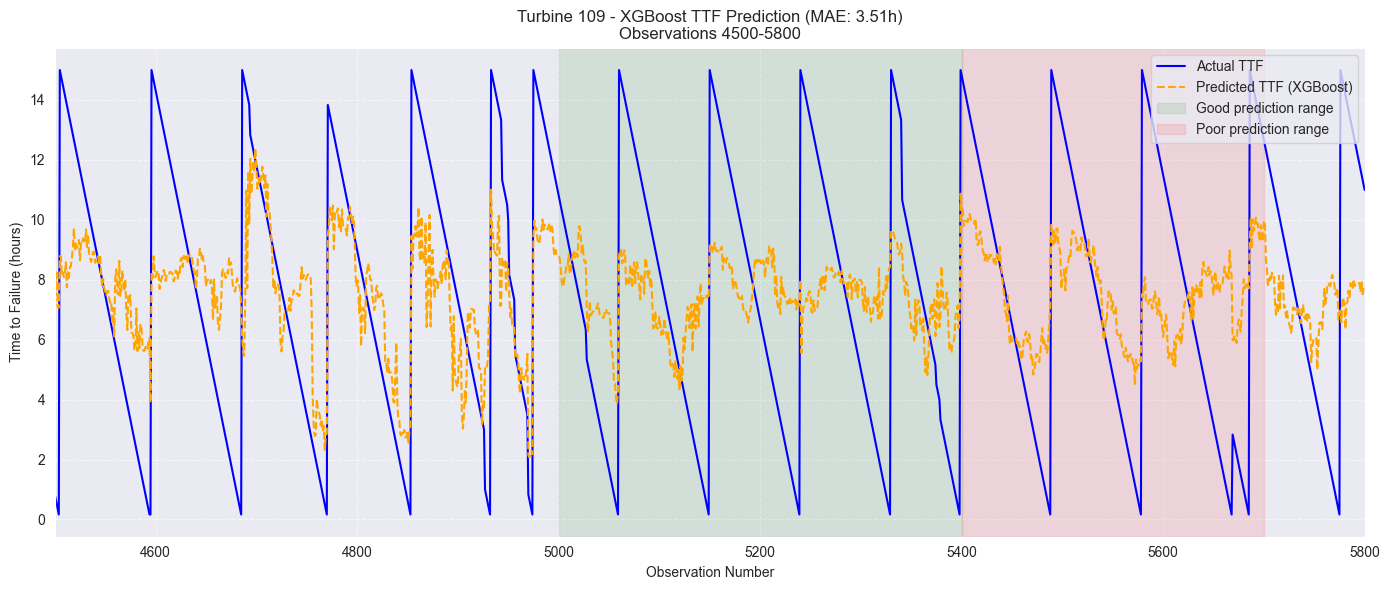

In [24]:
# 4. Plot results for specific turbines (4500-5800 range)
def plot_xgb_turbine_results(turbine_id, predictions, start_obs=4500, end_obs=5800):
    if turbine_id not in predictions:
        print(f"No data for turbine {turbine_id}")
        return

    data = predictions[turbine_id]
    obs_numbers = np.arange(len(data['timestamps']))

    # Filter for specified observation range
    mask = (obs_numbers >= start_obs) & (obs_numbers <= end_obs)
    if not any(mask):
        print(f"No data in range {start_obs}-{end_obs} for turbine {turbine_id}")
        return

    plt.figure(figsize=(14, 6))

    # Convert arrays to pandas Series if needed (or use direct array indexing)
    actual_values = data['actual'][mask] if hasattr(data['actual'], 'iloc') else data['actual'][mask]
    predicted_values = data['predicted'][mask] if hasattr(data['predicted'], 'iloc') else data['predicted'][mask]

    plt.plot(obs_numbers[mask], actual_values,
             label='Actual TTF', color='blue', linewidth=1.5)
    plt.plot(obs_numbers[mask], predicted_values,
             label='Predicted TTF (XGBoost)', color='orange', linestyle='--', linewidth=1.5)

    # Highlight ranges
    plt.axvspan(5000, 5400, alpha=0.1, color='green', label='Good prediction range')
    plt.axvspan(5400, 5700, alpha=0.1, color='red', label='Poor prediction range')

    plt.title(f"Turbine {turbine_id} - XGBoost TTF Prediction (MAE: {mae_results_xgb[turbine_id]:.2f}h)\n"
              f"Observations {start_obs}-{end_obs}")
    plt.xlabel("Observation Number")
    plt.ylabel("Time to Failure (hours)")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlim(start_obs, end_obs)
    plt.tight_layout()
    plt.show()

# Generate plots
plot_xgb_turbine_results(109, predictions_xgb, 4500, 5800)

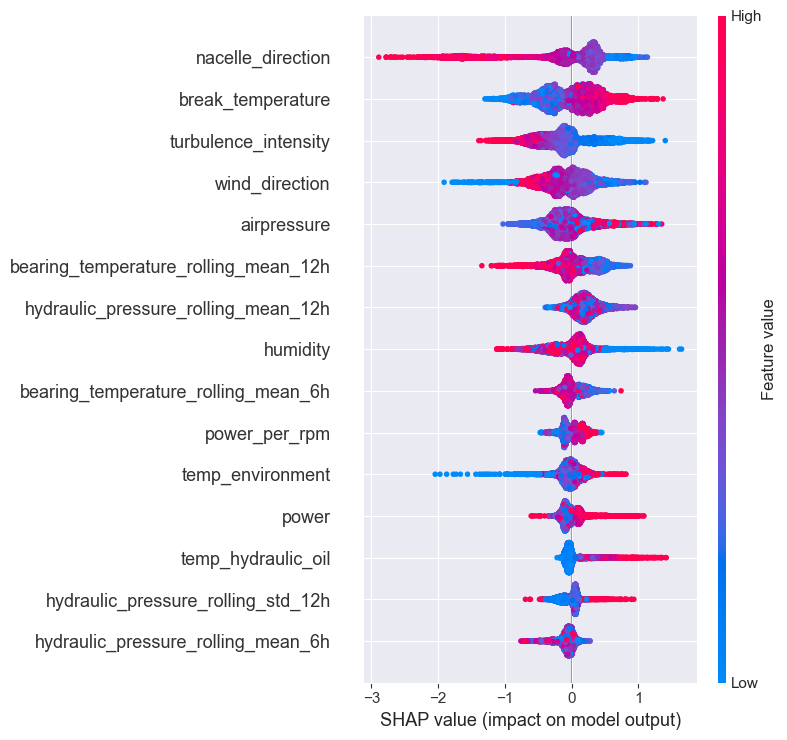

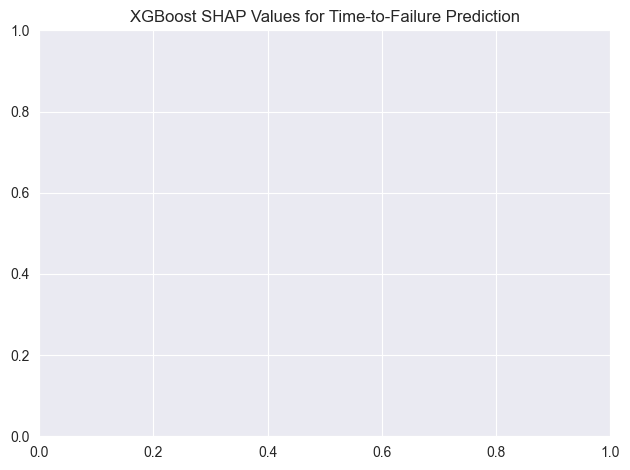

In [25]:
# 5. Feature Importance Analysis
if 109 in predictions_xgb:  # Use last trained model (turbine 109)
    explainer = shap.TreeExplainer(xgb_reg)
    shap_values = explainer.shap_values(X_test)

    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_test, feature_names=features, plot_type="dot", max_display=15)
    plt.title("XGBoost SHAP Values for Time-to-Failure Prediction")
    plt.tight_layout()
    plt.show()

In [26]:
# Create MAE results table for XGBoost only
if 'mae_results_xgb' not in locals():
    print("Error: Need to run XGBoost evaluation first")
else:
    # Create results DataFrame
    mae_results_df = pd.DataFrame({
        'Turbine ID': list(mae_results_xgb.keys()),
        'MAE (hours)': list(mae_results_xgb.values())
    }).set_index('Turbine ID').sort_values('MAE (hours)')

    # Style and display
    print("\nXGBoost Time-to-Failure Prediction Performance:")
    display(
        mae_results_df.style
        .background_gradient(cmap='YlOrRd', subset=['MAE (hours)'])
        .format("{:.2f}", subset=['MAE (hours)'])
        .set_caption("XGBoost Model MAE by Turbine")
        .highlight_min(subset=['MAE (hours)'], color='lightgreen')
        .highlight_max(subset=['MAE (hours)'], color='#ffcccb')
    )


XGBoost Time-to-Failure Prediction Performance:


,MAE (hours)
Turbine ID,
114,3.31
120,3.41
115,3.49
116,3.50
109,3.51
